In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 # modeling 
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

^C


## import the csv data as pandas dataframe

In [4]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Preparing X and Y variables 

In [12]:
X = df.drop(columns=['math score'])

In [13]:
X.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [14]:
y=df['math score']

In [15]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [25]:
# Creat column Transformer with 3 types of transformeers
X_df = df.drop(columns=['math score'])
num_features = X_df.select_dtypes(exclude=['object']).columns
cat_features = X_df.select_dtypes(include=['object']).columns


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()
preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ])

C:\Users\Admin\AppData\Local\Temp\ipykernel_3264\3432564751.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_df.select_dtypes(include=['object']).columns


In [27]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split

X = preprocessor.fit_transform(X_df)

In [28]:
# separate dataset into train and test 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape    

((800, 19), (200, 19), (800,), (200,))

# Create and Evaluate Function to give all metrics after model Training 

In [30]:
def evaluate_model(true,predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true,predicted)
    return mae,mse,rmse,r2_square

In [32]:
models={
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "AdaBoost": AdaBoostRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoost": CatBoostRegressor(verbose=False),
    }

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train) #Train model

    # make predictions a
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    # Evvaluate model
    
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print('- Root mean squared error is {}'.format(model_train_rmse))
    print('- Mean squared error is {}'.format(model_train_mse))
    print('- Mean absolute error is {}'.format(model_train_mae))
    print('- R2 score is {}'.format(model_train_r2))

    print("--------------------------------------------")

    print('Model performance for Test set')
    print('- Root mean squared error is {:.4f}'.format(model_test_rmse))
    print('- Mean squared error is {:.4f}'.format(model_test_mse))
    print('- Mean absolute error is {:.4f}'.format(model_test_mae))
    print('- R2 score is {:.4f}'.format(model_test_r2))
    r2_list.append(model_test_r2)

Model performance for Training set
- Root mean squared error is 5.323050852720514
- Mean squared error is 28.33487038064859
- Mean absolute error is 4.266711846071957
- R2 score is 0.8743172040139593
--------------------------------------------
Model performance for Test set
- Root mean squared error is 5.3940
- Mean squared error is 29.0952
- Mean absolute error is 4.2148
- R2 score is 0.8804
Model performance for Training set
- Root mean squared error is 5.323324922741654
- Mean squared error is 28.33778823308244
- Mean absolute error is 4.264987823725981
- R2 score is 0.8743042615212909
--------------------------------------------
Model performance for Test set
- Root mean squared error is 5.3904
- Mean squared error is 29.0563
- Mean absolute error is 4.2111
- R2 score is 0.8806
Model performance for Training set
- Root mean squared error is 6.593815587795568
- Mean squared error is 43.47840400585581
- Mean absolute error is 5.206302661246528
- R2 score is 0.8071462015863455
------

# Results

In [33]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2_score'])

,Model,R2_score
0,Linear Regression,0.880433
1,Ridge,0.880593
2,Lasso,0.825320
3,KNN,0.783813
4,Decision Tree,0.746094
5,Random Forest,0.853032
6,AdaBoost,0.856567
7,XGBRegressor,0.827797
8,CatBoost,0.851632


# Linear Regression 

In [34]:
lin_model = LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f" % score)

Accuracy of the model is 88.04


# Plot y_pred and y_test

Text(0, 0.5, 'Predicted Scores')

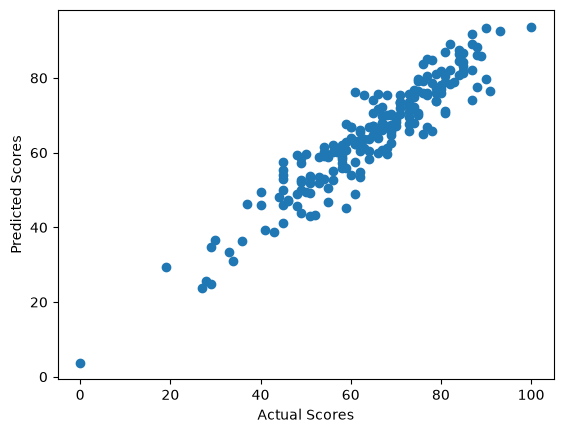

In [35]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

<Axes: xlabel='math score'>

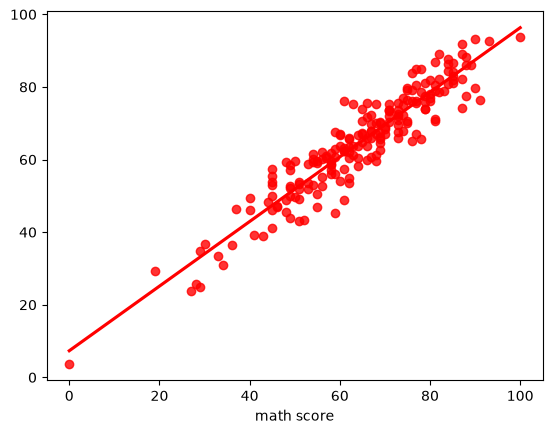

In [36]:
sns.regplot(x=y_test, y=y_pred, ci=None, color="red")

# Difference between Actual and Predicted values

In [38]:
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
predictions

,Actual,Predicted
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378
...,...,...
408,52,43.409149
332,62,62.152214
208,74,67.888395
613,65,67.022287
